# Dynamic Message Passing (cavity method) vs SIR on the CM grid

Goal: find a deterministic, near-unbiased estimator of the node-level SIR infection probability on configuration-model graphs. Two ideas come together here.

### 1. The recursive iteration in `recursiveIP_vs_sir_scatter_grid_cm.ipynb` is missing the seed prior.

That notebook iterates $p_v \leftarrow 1 - \prod_{u\sim v}(1 - p_u q_{uv})$ starting from $p_v = 1/n$ — the fixed point of a *self-sustaining* epidemic with no seed. The correct marginal for SIR with seed prior $p^0_v$ is
$$
p_v = 1 - (1 - p^0_v)\prod_{u\sim v}(1 - p_u\, q_{uv}).
$$
The $(1 - p^0_v)$ factor is what makes the approximation match the SIR convention of random 1% seeds.

### 2. The bigger fix: use non-backtracking messages (DMP / cavity method).

The RIP iteration above treats the messages coming into $v$ as independent, but when $v$ sends its state to neighbour $w$, the back-flow along $v \leftarrow w$ double-counts. DMP removes this by running messages on directed edges $(u \to v)$ with the convention "probability $u$ is infected via paths not through $v$":
$$
m_{j \to i} = 1 - (1 - p^0_j)\prod_{k \in \partial j \setminus \{i\}}\!\bigl(1 - q_{kj}\, m_{k \to j}\bigr).
$$
Marginal at node $i$ recombines all incoming messages:
$$
p_i = 1 - (1 - p^0_i)\prod_{k \in \partial i}\bigl(1 - q_{ki}\, m_{k \to i}\bigr).
$$
DMP is exact on trees and a controlled approximation on locally tree-like graphs (including CM). On dense graphs it retains a small systematic over-estimation due to loop correlations — visible as a near-constant bias offset.

### What this notebook compares

Four estimators of per-node infection probability on the same CM grid:
- **HKd**: heat-kernel diagonal $1 - [e^{-tL}]_{vv}$ with $t = \beta/\gamma$ (baseline from `heatK_vs_sir_scatter_grid_cm.ipynb`).
- **RIP-naive**: recursive IP from $p_v = 1/n$, no seed prior (as in `recursiveIP_vs_sir_scatter_grid_cm.ipynb`).
- **RIP-seeded**: the same fixed point iteration with the $(1 - p^0)$ prior.
- **DMP**: cavity / non-backtracking fixed point with the $(1 - p^0)$ prior.

Per-panel diagnostics: Pearson $\rho$ to SIR, MSE, and mean bias.

In [1]:
import sys
from pathlib import Path

for _root in (Path.cwd().resolve(), Path.cwd().resolve().parent):
    _py = _root / "src" / "python"
    if _py.is_dir():
        sys.path.insert(0, str(_py.resolve()))
        break

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse, stats
import scipy.sparse.linalg as _sla
from tqdm.auto import tqdm

from graph_sparsification.generators import configuration_model
from graph_sparsification.sir import sir_monte_carlo, calibrate_beta

if not hasattr(_sla, "_cg_orig"):
    _sla._cg_orig = _sla.cg


def _cg_compat(A, b, *args, **kwargs):
    if "tol" in kwargs:
        kwargs["rtol"] = kwargs.pop("tol")
    return _sla._cg_orig(A, b, *args, **kwargs)


_sla.cg = _cg_compat


def normalize_proximity_csr(W, prev_scale=1.0):
    W = sparse.csr_matrix(W, dtype=float).copy()
    if W.nnz == 0:
        return W, float(prev_scale)
    mx = float(W.data.max())
    if mx <= 0:
        return W, float(prev_scale)
    W.data = np.clip(W.data / mx, 1e-12, 1.0 - 1e-12)
    return W, float(prev_scale * mx)


def generate_config_model(n, degree_dist, weight_dist, seed=None):
    rng = np.random.default_rng(seed)

    def degree_sampler(nn, r):
        return np.asarray(degree_dist(nn), dtype=int)

    def weight_sampler(m, r):
        return np.asarray(weight_dist(m), dtype=float)

    W = configuration_model(n, degree_sampler, weight_sampler, rng=rng)
    W, _ = normalize_proximity_csr(W, 1.0)
    return W


def heat_kernel_diag(W_prox, beta, gamma, t=None):
    W = sparse.csr_matrix(W_prox, dtype=np.float64).toarray()
    n = W.shape[0]
    if n == 0:
        return np.zeros(0, dtype=np.float64)
    if not np.any(W):
        return np.zeros(n, dtype=np.float64)
    deg = W.sum(axis=1).ravel()
    L = np.diag(deg) - W
    L = 0.5 * (L + L.T)
    t_use = (float(beta) / float(gamma)) if (t is None and gamma > 0) else (float(beta) if t is None else float(t))
    evals, V = np.linalg.eigh(L)
    d = np.exp(-t_use * evals)
    return 1.0 - np.sum((V * V) * d, axis=1)


def rip_naive(W, beta, gamma, max_iter=2000, tol=1e-9):
    """RIP as in recursiveIP_vs_sir_scatter_grid_cm.ipynb: start p=1/n, no seed prior."""
    W = sparse.csr_matrix(W, dtype=float)
    n = W.shape[0]
    coo = W.tocoo()
    rows, cols = coo.row.astype(np.int64), coo.col.astype(np.int64)
    wvals = coo.data.astype(np.float64)
    q = float(beta) * wvals / (float(beta) * wvals + float(gamma))
    p = np.full(n, 1.0 / n)
    for it in range(max_iter):
        terms = np.clip(1.0 - p[rows] * q, 1e-300, 1.0)
        logp = np.zeros(n)
        np.add.at(logp, cols, np.log(terms))
        p_new = np.clip(1.0 - np.exp(logp), 0.0, 1.0)
        if np.max(np.abs(p_new - p)) < tol:
            return p_new, it + 1
        p = p_new
    return p, max_iter


def rip_seeded(W, beta, gamma, p0, max_iter=2000, tol=1e-9):
    """Same iteration but with the (1 - p0) prior; start p = p0."""
    W = sparse.csr_matrix(W, dtype=float)
    n = W.shape[0]
    coo = W.tocoo()
    rows, cols = coo.row.astype(np.int64), coo.col.astype(np.int64)
    wvals = coo.data.astype(np.float64)
    q = float(beta) * wvals / (float(beta) * wvals + float(gamma))
    p0 = float(p0)
    p = np.full(n, p0)
    for it in range(max_iter):
        terms = np.clip(1.0 - p[rows] * q, 1e-300, 1.0)
        logp = np.zeros(n)
        np.add.at(logp, cols, np.log(terms))
        p_new = np.clip(1.0 - (1.0 - p0) * np.exp(logp), 0.0, 1.0)
        if np.max(np.abs(p_new - p)) < tol:
            return p_new, it + 1
        p = p_new
    return p, max_iter


def dmp_sir(W, beta, gamma, p0, max_iter=2000, tol=1e-9):
    """Dynamic Message Passing / cavity fixed point for SIR at t=infinity.
    Messages m[e=(j->i)] = P(j infected via paths not through i).
    """
    W = sparse.csr_matrix(W, dtype=float)
    n = W.shape[0]
    coo = W.tocoo()
    src = coo.row.astype(np.int64)
    dst = coo.col.astype(np.int64)
    wvals = coo.data.astype(np.float64)
    q = float(beta) * wvals / (float(beta) * wvals + float(gamma))
    E = src.size

    # Reverse-edge lookup: pair (u->v) with (v->u) since W is symmetric.
    key2idx = {}
    for e in range(E):
        key2idx[(int(src[e]), int(dst[e]))] = e
    rev = np.empty(E, dtype=np.int64)
    for e in range(E):
        rev[e] = key2idx[(int(dst[e]), int(src[e]))]

    p0a = np.full(n, float(p0))
    m = p0a[src].copy()

    for it in range(max_iter):
        log_term = np.log(np.clip(1.0 - q * m, 1e-300, 1.0))
        node_log = np.zeros(n)
        np.add.at(node_log, dst, log_term)
        # For edge (j->i), exclude back-flow from (i->j).
        excl = node_log[src] - log_term[rev]
        m_new = np.clip(1.0 - (1.0 - p0a[src]) * np.exp(excl), 0.0, 1.0)
        diff = float(np.max(np.abs(m_new - m)))
        m = m_new
        if diff < tol:
            break

    log_term = np.log(np.clip(1.0 - q * m, 1e-300, 1.0))
    node_log = np.zeros(n)
    np.add.at(node_log, dst, log_term)
    p = np.clip(1.0 - (1.0 - p0a) * np.exp(node_log), 0.0, 1.0)
    return p, it + 1


def run_sir_original(W, beta, gamma, patient_zeros, t_max, n_runs, seed):
    rng = np.random.default_rng(seed)
    res = sir_monte_carlo(
        sparse.csr_matrix(W, dtype=float),
        float(beta),
        float(gamma),
        initial_infected=patient_zeros,
        n_runs=int(n_runs),
        t_max=float(t_max),
        rng=rng,
        use_cpp=True,
    )
    return res["infection_prob"]


def calibrate_beta_notebook(W_prox, sir_gamma, sir_patient_zeros, sir_t_max, seed,
                            target_range=(0.45, 0.7), start_beta=1.0,
                            beta_low=0.001, beta_high=1000.0, max_iters=20,
                            n_probe_runs=20, verbose=False):
    rng = np.random.default_rng(seed)
    beta, info = calibrate_beta(
        sparse.csr_matrix(W_prox, dtype=float),
        gamma=float(sir_gamma),
        target_range=target_range,
        initial_infected=sir_patient_zeros,
        n_calibration_runs=int(n_probe_runs),
        t_max=float(sir_t_max),
        rng=rng,
        beta_min=float(beta_low),
        beta_max=float(beta_high),
        max_iterations=int(max_iters),
        verbose=verbose,
        start_beta=float(start_beta),
    )
    return beta, float(info["mean_infection"])


def _rho(x, y):
    if np.std(x) > 1e-15 and np.std(y) > 1e-15:
        return float(np.corrcoef(x, y)[0, 1])
    return float("nan")


In [2]:
n_nodes = 500
sir_gamma = 1.0
sir_t_max = 100.0
sir_n_runs = 2000          # bumped from 1000 -> 2000 to reduce SIR MC noise
sir_patient_zeros = 0.01   # fraction (per run)

rip_max_iter = 2000
rip_tol = 1e-9

# Restrict grid for quick runs (use slice(None) for full grid)
CM_ROW_SLICE = slice(None)
CM_COL_SLICE = slice(None)


In [3]:
degree_configs = [
    ("Unif(1,50)", lambda n: np.maximum(1, np.minimum(n - 1, np.random.randint(1, 51, n)))),
    ("Unif(1,100)", lambda n: np.maximum(1, np.minimum(n - 1, np.random.randint(1, 101, n)))),
    ("Exp(scale=30)", lambda n: np.maximum(1, np.minimum(n - 1, np.ceil(np.random.exponential(30, n)).astype(int)))),
    ("Exp(scale=60)", lambda n: np.maximum(1, np.minimum(n - 1, np.ceil(np.random.exponential(60, n)).astype(int)))),
    ("LogNorm(\u03bc=3.26,\u03c3=0.66)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(np.exp(np.random.normal(3.26, 0.66, n))).astype(int)))),
    ("LogNorm(\u03bc=3.26,\u03c3=2)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(np.exp(np.random.normal(3.26, 2, n))).astype(int)))),
    ("Pareto(\u03b1=2.5,\u03c3=20)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(stats.pareto.rvs(b=2.5, scale=20, size=n)).astype(int)))),
    ("Pareto(\u03b1=1.5,\u03c3=30)", lambda n: np.maximum(1, np.minimum(n - 1, np.round(stats.pareto.rvs(b=1.5, scale=30, size=n)).astype(int)))),
]

weight_configs = [
    ("Exp(1/30)", lambda m: np.maximum(1e-9, np.random.exponential(1 / 30, m))),
    ("Exp(1)", lambda m: np.maximum(1e-9, np.random.exponential(1, m))),
    ("Exp(30)", lambda m: np.maximum(1e-9, np.random.exponential(30, m))),
    ("LogNorm(2,1)", lambda m: np.maximum(1e-9, np.random.lognormal(2, 1, m))),
    ("LogLogNorm(1.2,0.4)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(1.2, 0.4, m))))),
    ("LogLogNorm(1.2,0.8)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(1.2, 0.8, m))))),
    ("LogLogNorm(2,0.8)", lambda m: np.maximum(1e-9, np.exp(np.exp(np.random.normal(2, 0.8, m))))),
]


## Single-graph pilot: all four estimators vs SIR

Before the full grid, check on one heavy-tail cell that DMP is in the right ballpark.

Pareto(α=1.5,σ=30) / LogNorm(2,1): n=500, edges=14774, mean degree=59.1
calibrated β = 0.5005  (⟨p⟩ ≈ 0.497)

method          iters        ρ         MSE      bias    mean
HKd                 -   0.9830     0.02904   +0.1675   0.662
RIP-naive          27   0.9985    0.003736   +0.0561   0.550
RIP-seeded         25   0.9985    0.004415   +0.0626   0.557
DMP                25   0.9985    0.003707   +0.0568   0.551
SIR                 -        -           -         -   0.494


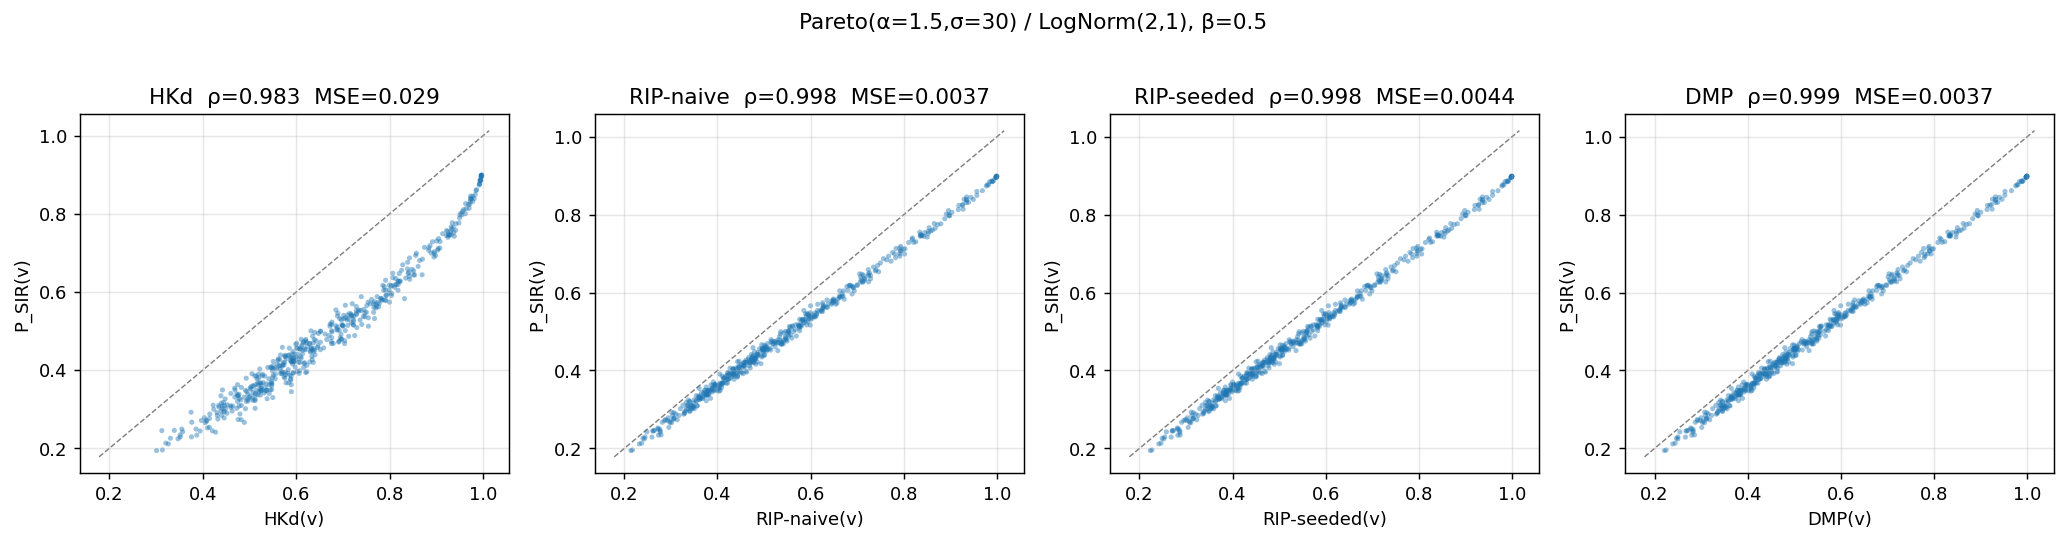

In [4]:
pilot_i, pilot_j = 7, 3   # Pareto(1.5,30) degrees x LogNorm(2,1) weights
deg_label, deg_fn = degree_configs[pilot_i]
wgt_label, wgt_fn = weight_configs[pilot_j]
W = generate_config_model(n_nodes, deg_fn, wgt_fn, seed=42 + pilot_i * 10 + pilot_j)
W = sparse.csr_matrix(W, dtype=float)
print(f"{deg_label} / {wgt_label}: n={W.shape[0]}, edges={W.nnz // 2}, mean degree={W.getnnz(axis=1).mean():.1f}")

cal_seed = 1000 + pilot_i * 10 + pilot_j
beta, mean_p_cal = calibrate_beta_notebook(W, sir_gamma, sir_patient_zeros, sir_t_max, cal_seed)
print(f"calibrated \u03b2 = {beta:.4g}  (\u27e8p\u27e9 \u2248 {mean_p_cal:.3f})")

p_sir = run_sir_original(W, beta, sir_gamma, sir_patient_zeros, sir_t_max, sir_n_runs, seed=cal_seed + 10_000)

p_hkd = heat_kernel_diag(W, beta, sir_gamma)
p_rn, it_rn = rip_naive(W, beta, sir_gamma, max_iter=rip_max_iter, tol=rip_tol)
p_rs, it_rs = rip_seeded(W, beta, sir_gamma, p0=sir_patient_zeros, max_iter=rip_max_iter, tol=rip_tol)
p_dm, it_dm = dmp_sir(W, beta, sir_gamma, p0=sir_patient_zeros, max_iter=rip_max_iter, tol=rip_tol)

print(f"\n{'method':<14}{'iters':>7}{'\u03c1':>9}{'MSE':>12}{'bias':>10}{'mean':>8}")
for name, p, it in [("HKd", p_hkd, None), ("RIP-naive", p_rn, it_rn),
                     ("RIP-seeded", p_rs, it_rs), ("DMP", p_dm, it_dm)]:
    its = "-" if it is None else f"{it}"
    print(f"{name:<14}{its:>7}{_rho(p, p_sir):>9.4f}{float(np.mean((p-p_sir)**2)):>12.4g}"
          f"{float(np.mean(p-p_sir)):>+10.4f}{p.mean():>8.3f}")
print(f"{'SIR':<14}{'-':>7}{'-':>9}{'-':>12}{'-':>10}{p_sir.mean():>8.3f}")

# Quick visual: each estimator vs SIR.
fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=130)
for ax, (name, p) in zip(axes, [("HKd", p_hkd), ("RIP-naive", p_rn), ("RIP-seeded", p_rs), ("DMP", p_dm)]):
    ax.scatter(p, p_sir, s=8, alpha=0.45, c="tab:blue", edgecolors="none", rasterized=True)
    lo = float(min(p.min(), p_sir.min()))
    hi = float(max(p.max(), p_sir.max()))
    pad = 0.02 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], c="0.5", lw=0.8, ls="--", zorder=0)
    ax.set_xlabel(f"{name}(v)")
    ax.set_ylabel("P_SIR(v)")
    ax.set_title(f"{name}  \u03c1={_rho(p, p_sir):.3f}  MSE={float(np.mean((p-p_sir)**2)):.2g}")
    ax.grid(True, alpha=0.3)
fig.suptitle(f"{deg_label} / {wgt_label}, \u03b2={beta:.3g}", y=1.03)
fig.tight_layout()
plt.show()


## Full CM grid: per-panel comparison of all four estimators against SIR

For each (degree, weight) cell: scatter the four estimators on the same axes against $P_{\rm SIR}$, with $y = x$ reference. Title reports Pearson $\rho$ and MSE for each; mean bias is collected separately.

CM grid:   0%|          | 0/56 [00:00<?, ?it/s]

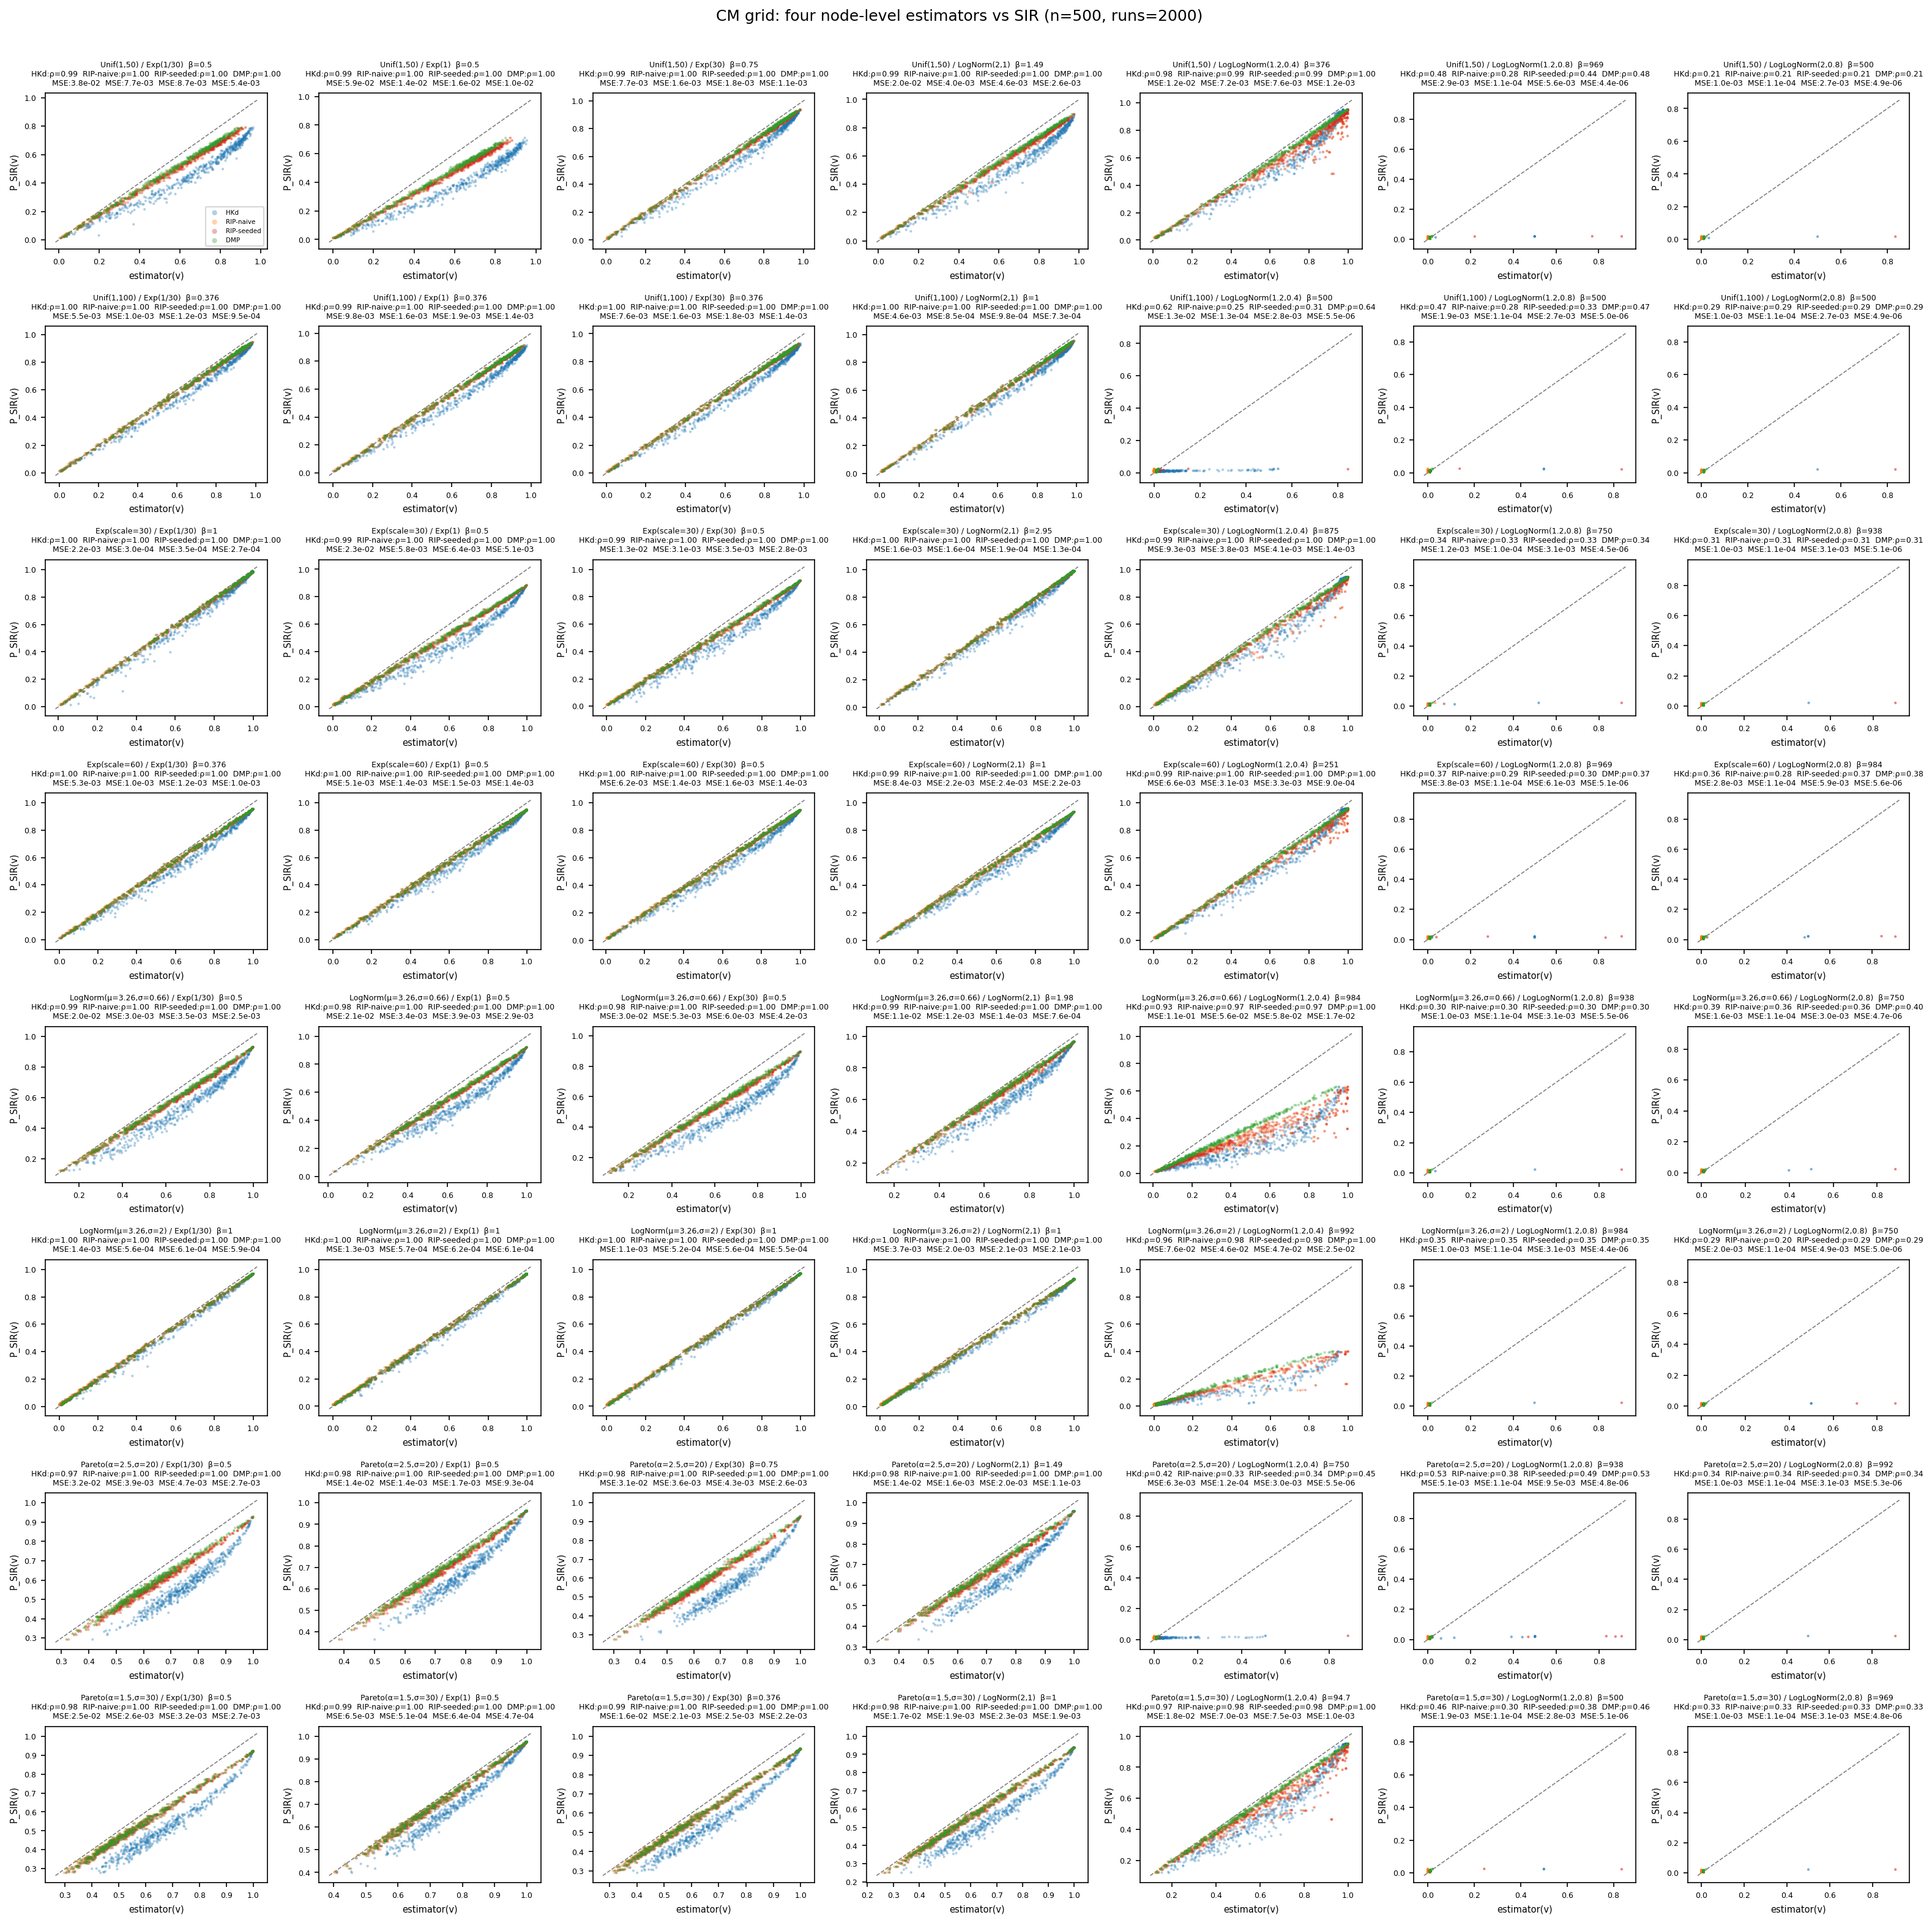

In [5]:
row_idx = list(range(len(degree_configs)))[CM_ROW_SLICE]
col_idx = list(range(len(weight_configs)))[CM_COL_SLICE]
n_r, n_c = len(row_idx), len(col_idx)

fig, axes = plt.subplots(n_r, n_c, figsize=(3.0 * n_c, 2.6 * n_r), squeeze=False, dpi=150)

method_names = ["HKd", "RIP-naive", "RIP-seeded", "DMP"]
method_colors = {"HKd": "tab:blue", "RIP-naive": "tab:orange", "RIP-seeded": "tab:red", "DMP": "tab:green"}

rho_grid = {m: np.full((n_r, n_c), np.nan) for m in method_names}
mse_grid = {m: np.full((n_r, n_c), np.nan) for m in method_names}
bias_grid = {m: np.full((n_r, n_c), np.nan) for m in method_names}
beta_grid = np.full((n_r, n_c), np.nan)

tasks = [(ii, i, jj, j) for ii, i in enumerate(row_idx) for jj, j in enumerate(col_idx)]

for ii, i, jj, j in tqdm(tasks, desc="CM grid"):
    deg_label, deg_fn = degree_configs[i]
    wgt_label, wgt_fn = weight_configs[j]
    W = generate_config_model(n_nodes, deg_fn, wgt_fn, seed=42 + i * 10 + j)
    W = sparse.csr_matrix(W, dtype=float)

    cal_seed = 1000 + i * 10 + j
    beta, _ = calibrate_beta_notebook(W, sir_gamma, sir_patient_zeros, sir_t_max, cal_seed)
    beta_grid[ii, jj] = beta

    p_sir = run_sir_original(W, beta, sir_gamma, sir_patient_zeros, sir_t_max, sir_n_runs, seed=cal_seed + 10_000)

    preds = {
        "HKd": heat_kernel_diag(W, beta, sir_gamma),
        "RIP-naive": rip_naive(W, beta, sir_gamma, max_iter=rip_max_iter, tol=rip_tol)[0],
        "RIP-seeded": rip_seeded(W, beta, sir_gamma, p0=sir_patient_zeros, max_iter=rip_max_iter, tol=rip_tol)[0],
        "DMP": dmp_sir(W, beta, sir_gamma, p0=sir_patient_zeros, max_iter=rip_max_iter, tol=rip_tol)[0],
    }

    ax = axes[ii, jj]
    all_vals = [p_sir] + list(preds.values())
    lo = float(min(np.min(v) for v in all_vals))
    hi = float(max(np.max(v) for v in all_vals))
    pad = 0.02 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], c="0.5", lw=0.8, ls="--", zorder=0)

    for m in method_names:
        p = preds[m]
        rho_grid[m][ii, jj] = _rho(p, p_sir)
        mse_grid[m][ii, jj] = float(np.mean((p - p_sir) ** 2))
        bias_grid[m][ii, jj] = float(np.mean(p - p_sir))
        ax.scatter(p, p_sir, s=4, alpha=0.35, c=method_colors[m], label=m, edgecolors="none", rasterized=True)

    lines = [
        f"{deg_label} / {wgt_label}  \u03b2={beta:.3g}",
        "  ".join(f"{m}:\u03c1={rho_grid[m][ii,jj]:.2f}" for m in method_names),
        "  ".join(f"MSE:{mse_grid[m][ii,jj]:.1e}" for m in method_names),
    ]
    ax.set_title("\n".join(lines), fontsize=6)
    ax.set_xlabel("estimator(v)", fontsize=7)
    ax.set_ylabel("P_SIR(v)", fontsize=7)
    ax.tick_params(labelsize=6)
    if ii == 0 and jj == 0:
        ax.legend(loc="lower right", fontsize=5, markerscale=2)

fig.suptitle(f"CM grid: four node-level estimators vs SIR (n={n_nodes}, runs={sir_n_runs})", y=1.005)
fig.tight_layout()
plt.show()


## Aggregate summary across the grid

Per-method medians of $\rho$, MSE, mean bias across all cells, plus heatmaps of per-cell bias so the dependence on graph density is visible.

method         median ρ   median MSE  median bias   max |bias|
--------------------------------------------------------------
HKd              0.9835     6.38e-03      +0.0688       0.2935
RIP-naive        0.9974     1.27e-03      +0.0306       0.1826
RIP-seeded       0.9974     3.05e-03      +0.0349       0.1914
DMP              0.9987     9.40e-04      +0.0276       0.1040


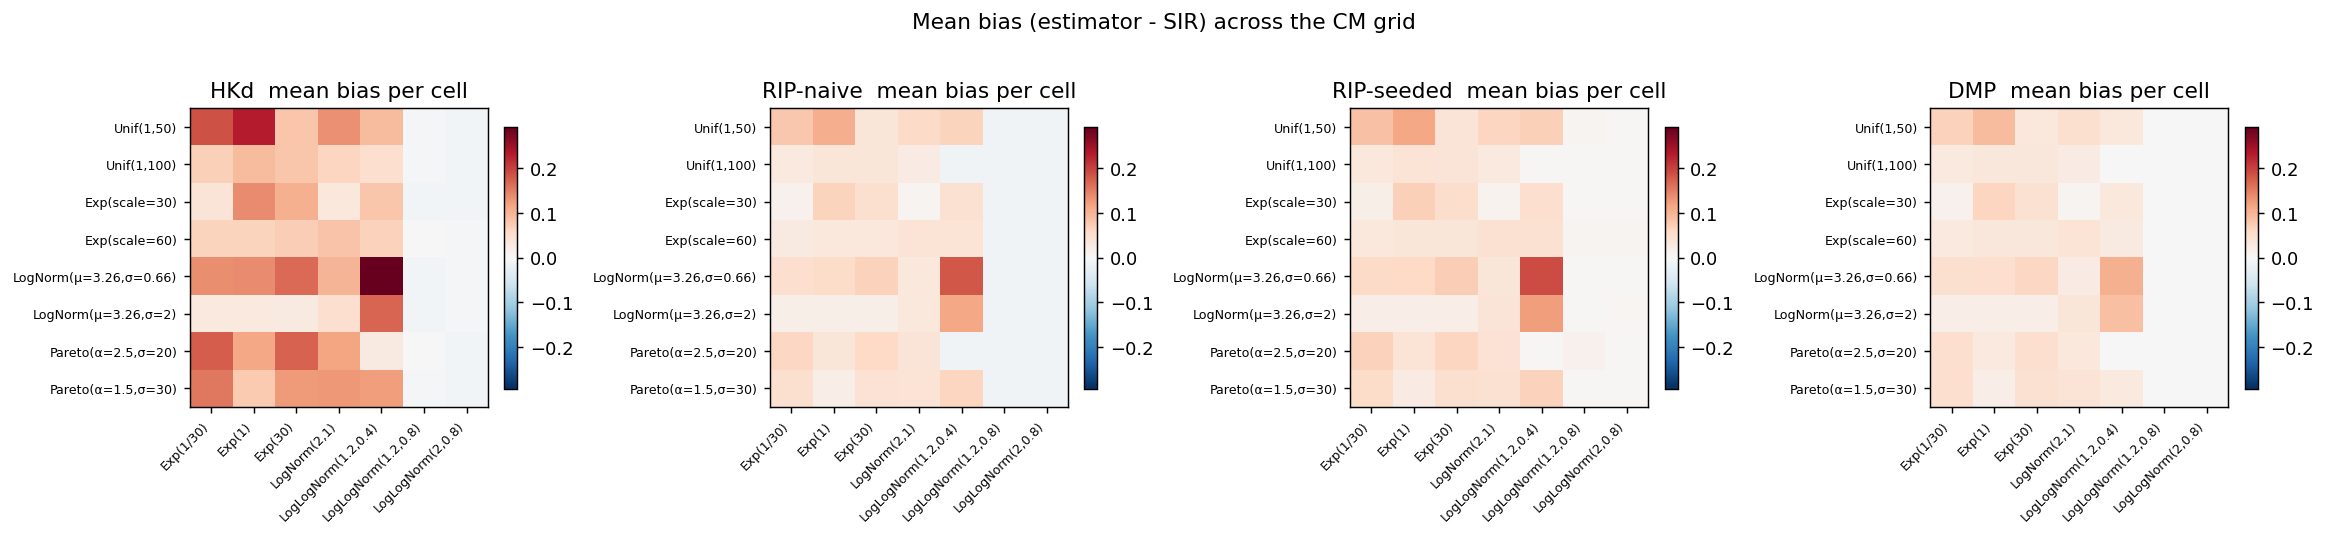

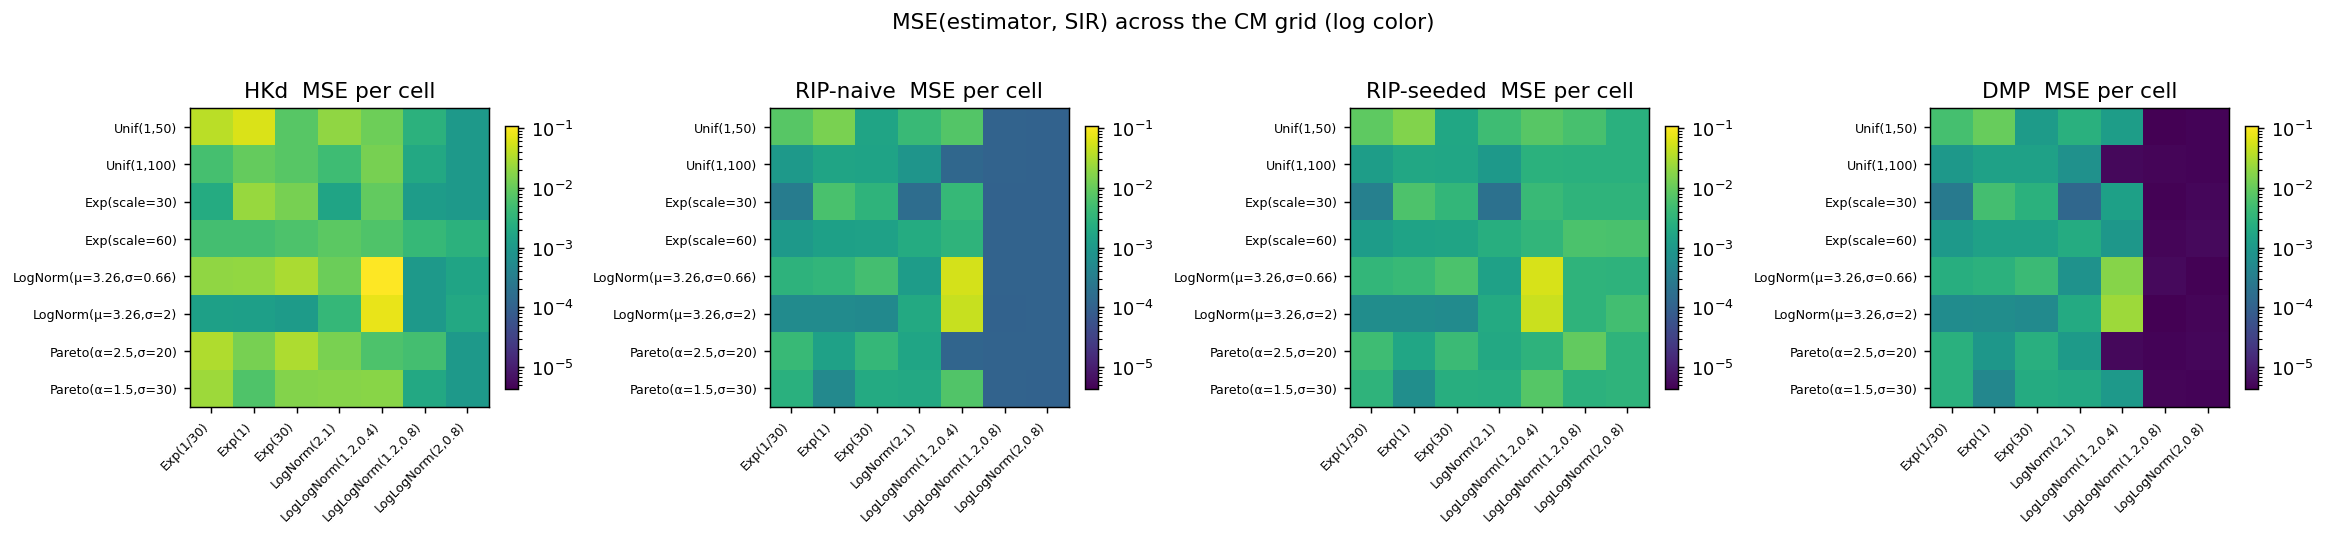

In [6]:
print(f"{'method':<12} {'median \u03c1':>10} {'median MSE':>12} {'median bias':>12} {'max |bias|':>12}")
print("-" * 62)
for m in method_names:
    r = np.nanmedian(rho_grid[m])
    mse_med = np.nanmedian(mse_grid[m])
    b_med = np.nanmedian(bias_grid[m])
    b_max = np.nanmax(np.abs(bias_grid[m]))
    print(f"{m:<12} {r:>10.4f} {mse_med:>12.2e} {b_med:>+12.4f} {b_max:>12.4f}")

# Bias heatmap per method.
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=130)
vmax = max(np.nanmax(np.abs(bias_grid[m])) for m in method_names)
for ax, m in zip(axes, method_names):
    im = ax.imshow(bias_grid[m], cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(f"{m}  mean bias per cell")
    ax.set_xticks(range(n_c))
    ax.set_xticklabels([weight_configs[j][0] for j in col_idx], rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n_r))
    ax.set_yticklabels([degree_configs[i][0] for i in row_idx], fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle("Mean bias (estimator - SIR) across the CM grid", y=1.02)
fig.tight_layout()
plt.show()

# MSE heatmap (log scale).
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=130)
vmin = min(np.nanmin(mse_grid[m][mse_grid[m] > 0]) for m in method_names)
vmax = max(np.nanmax(mse_grid[m]) for m in method_names)
from matplotlib.colors import LogNorm
for ax, m in zip(axes, method_names):
    im = ax.imshow(mse_grid[m], cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax), aspect="auto")
    ax.set_title(f"{m}  MSE per cell")
    ax.set_xticks(range(n_c))
    ax.set_xticklabels([weight_configs[j][0] for j in col_idx], rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n_r))
    ax.set_yticklabels([degree_configs[i][0] for i in row_idx], fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle("MSE(estimator, SIR) across the CM grid (log color)", y=1.02)
fig.tight_layout()
plt.show()


## Bias is approximately constant per graph — a single scalar correction helps

DMP over-estimates $P_{\rm SIR}$ by a near-constant offset on dense graphs (loop correlations the cavity ignores). A quick way to check "how much bias is avoidable without Monte Carlo" is to subtract the per-cell mean bias from DMP and see if the residual is just noise. If it is, the bias structure is one global scalar per graph that could be estimated from a *very* short SIR probe (a dozen runs). The cell below does this post-hoc, using the SIR ground truth as the reference — it's a ceiling of what de-biasing can achieve, not a fair online estimator.

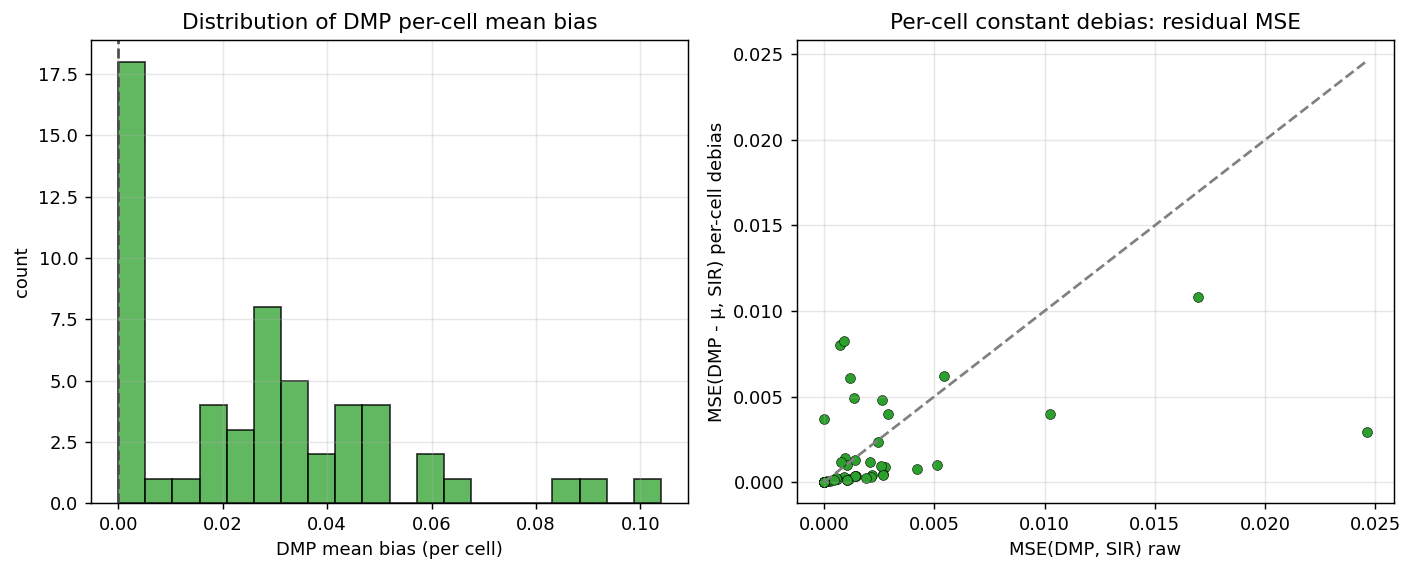

DMP      median MSE raw      = 9.40e-04
DMP      median MSE debiased = 2.95e-04


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=130)

axes[0].hist(bias_grid["DMP"].ravel(), bins=20, color="tab:green", alpha=0.75, edgecolor="k")
axes[0].axvline(0, c="0.3", ls="--")
axes[0].set_xlabel("DMP mean bias (per cell)")
axes[0].set_ylabel("count")
axes[0].set_title("Distribution of DMP per-cell mean bias")
axes[0].grid(True, alpha=0.3)

rho_dm_after = np.full_like(rho_grid["DMP"], np.nan)
mse_dm_after = np.full_like(mse_grid["DMP"], np.nan)
for ii, i in enumerate(row_idx):
    for jj, j in enumerate(col_idx):
        # Fast recomputation from scratch to apply per-cell debias.
        deg_fn = degree_configs[i][1]
        wgt_fn = weight_configs[j][1]
        W = generate_config_model(n_nodes, deg_fn, wgt_fn, seed=42 + i * 10 + j)
        W = sparse.csr_matrix(W, dtype=float)
        beta = beta_grid[ii, jj]
        p_sir = run_sir_original(W, beta, sir_gamma, sir_patient_zeros, sir_t_max, sir_n_runs,
                                 seed=1000 + i * 10 + j + 10_000)
        p_dm, _ = dmp_sir(W, beta, sir_gamma, p0=sir_patient_zeros, max_iter=rip_max_iter, tol=rip_tol)
        p_dm_c = np.clip(p_dm - bias_grid["DMP"][ii, jj], 0.0, 1.0)
        rho_dm_after[ii, jj] = _rho(p_dm_c, p_sir)
        mse_dm_after[ii, jj] = float(np.mean((p_dm_c - p_sir) ** 2))

axes[1].scatter(mse_grid["DMP"].ravel(), mse_dm_after.ravel(), c="tab:green", s=30, edgecolors="k", linewidths=0.3)
mx = float(max(np.nanmax(mse_grid["DMP"]), np.nanmax(mse_dm_after)))
axes[1].plot([0, mx], [0, mx], c="0.5", ls="--")
axes[1].set_xlabel("MSE(DMP, SIR) raw")
axes[1].set_ylabel("MSE(DMP - \u00b5, SIR) per-cell debias")
axes[1].set_title("Per-cell constant debias: residual MSE")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"DMP      median MSE raw      = {np.nanmedian(mse_grid['DMP']):.2e}")
print(f"DMP      median MSE debiased = {np.nanmedian(mse_dm_after):.2e}")
